In [4]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [6]:
from keras.datasets import fashion_mnist
(x_data,y_data),(tt_x,tt_y) = fashion_mnist.load_data()

In [7]:
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, test_size=0.2)

In [8]:
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [9]:
e_tr_x = s_tr_x.reshape(-1, 28, 28, 1)
e_tt_x = s_tt_x.reshape(-1, 28, 28, 1)
e_val_x = s_val_x.reshape(-1, 28, 28, 1)

In [10]:
from keras.utils import to_categorical
e_tr_y=to_categorical(tr_y)
e_tt_y=to_categorical(tt_y)
e_val_y=to_categorical(val_y)

In [11]:
# e_tr_y = tr_y.reshape(-1, 1)

In [12]:
e_tr_x.shape, e_tr_y.shape

((48000, 28, 28, 1), (48000, 10))

In [24]:
# CNN model
m = Sequential()
m.add(Input(shape=e_tr_x.shape[1:])) # 28, 28, 1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28, 28, 32
m.add(MaxPooling2D(2)) # 14, 14, 32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14, 14, 64
m.add(MaxPooling2D(2)) # 7, 7, 64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7, 7, 128
m.add(MaxPooling2D(2)) # 3, 3, 128
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 3, 3, 256
m.add(MaxPooling2D(2)) # 1, 1, 256 <- 여기까진 이미지로 남아있다
m.add(Flatten()) # 여기서 벡터로 변환

m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
m.predict(e_tr_x).shape# 초기 가중치가 설정되어 있다.

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


(48000, 10)

In [26]:
e_tr_y.shape

(48000, 10)

In [27]:
py = m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [28]:
ty = e_tr_y

In [29]:
np.argmax(py, axis=1)

array([4, 4, 4, ..., 5, 4, 4])

In [30]:
ty[0]>0.5

array([False, False, False, False, False, False, False, False,  True,
       False])

In [31]:
np.argmax(ty, axis=1)

array([8, 8, 6, ..., 3, 1, 3])

In [32]:
print(classification_report(np.argmax(py, axis=1),np.argmax(ty, axis=1)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.01      0.09      0.02       563
           3       0.00      0.00      0.00         0
           4       0.79      0.17      0.29     21788
           5       0.51      0.20      0.29     12463
           6       0.20      0.07      0.11     13186
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0

    accuracy                           0.15     48000
   macro avg       0.15      0.05      0.07     48000
weighted avg       0.55      0.15      0.23     48000



/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
m.compile(loss='categorical_crossentropy', metrics=['acc'])

In [34]:
m_ck1 = ModelCheckpoint('best_m.keras', save_best_only=True)
m_ck2 = ModelCheckpoint(filepath='best_m.weights.h5', save_weights_only=True)

In [35]:
hy = m.fit(e_tr_x, e_tr_y, validation_split=0.2, epochs=10, callbacks=[m_ck1, m_ck2])

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - acc: 0.7001 - loss: 0.7898 - val_acc: 0.8731 - val_loss: 0.3380
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.8750 - loss: 0.3351 - val_acc: 0.8929 - val_loss: 0.3043
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.8971 - loss: 0.2732 - val_acc: 0.9091 - val_loss: 0.2534
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9145 - loss: 0.2278 - val_acc: 0.9042 - val_loss: 0.2772
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.9205 - loss: 0.2152 - val_acc: 0.9116 - val_loss: 0.2598
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9308 - loss: 0.1863 - val_acc: 0.9172 - val_loss: 0.2653
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9341 - loss: 0.1719 - val_acc: 0.9045 - val_loss: 0.3011
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.9405 - loss: 0.1572 - val_acc: 0.9120 - val_loss: 0.2796
Epoch 9/10
1200/1200 ━━━

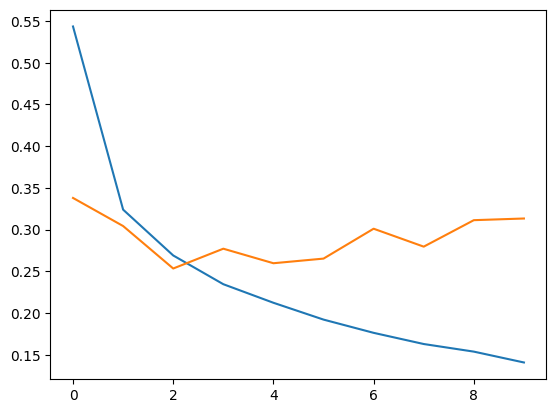

In [36]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

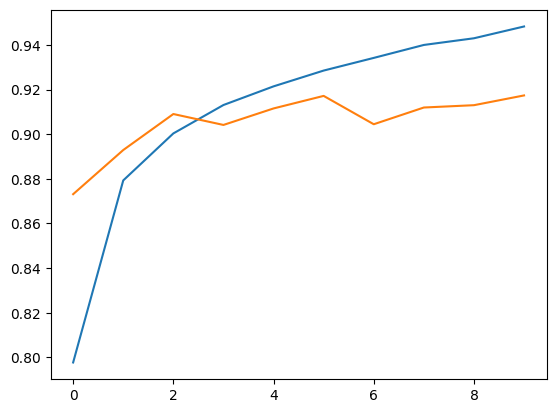

In [37]:
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [38]:
tr_scs = m.evaluate(e_tr_x, e_tr_y)
val_scs = m.evaluate(e_val_x, e_val_y)
tt_scs = m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9586 - loss: 0.1218
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9189 - loss: 0.3012
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9072 - loss: 0.3734


In [39]:
tr_scs

[0.1599322408437729, 0.9492916464805603]

In [40]:
all_acc=abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]-tt_scs[1])+abs(tt_scs[1]-val_scs[1])
all_acc

0.08478331565856934

In [41]:
all_loss=abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]-tt_scs[0])+abs(tt_scs[0]-val_scs[0])
all_loss

0.39741286635398865

In [42]:
np.abs([1, -2, 3])

array([1, 2, 3])

In [43]:
py=m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [44]:
print(classification_report(np.argmax(py, axis=1),np.argmax(ty, axis=1)))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      4707
           1       0.99      1.00      1.00      4812
           2       0.95      0.89      0.92      5054
           3       0.95      0.97      0.96      4734
           4       0.95      0.88      0.91      5157
           5       0.96      1.00      0.98      4605
           6       0.82      0.91      0.86      4327
           7       0.98      0.95      0.97      4964
           8       0.99      1.00      0.99      4820
           9       0.98      0.98      0.98      4820

    accuracy                           0.95     48000
   macro avg       0.95      0.95      0.95     48000
weighted avg       0.95      0.95      0.95     48000



In [46]:
# 완성된 모델로 예측을 위한 준비
l_m = load_model('best_m.keras')
l_m

<Sequential name=sequential, built=True>

In [47]:
m.evaluate(e_tr_x, e_tr_y)
l_m.evaluate(e_tr_x, e_tr_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9586 - loss: 0.1218
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9238 - loss: 0.2089


[0.2198360413312912, 0.9194583296775818]

In [48]:
m.evaluate(e_tt_x, e_tt_y)
l_m.evaluate(e_tt_x, e_tt_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9072 - loss: 0.3734
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8988 - loss: 0.2854


[0.2809167802333832, 0.8980000019073486]

In [49]:
m.evaluate(e_val_x, e_val_y)
l_m.evaluate(e_val_x, e_val_y)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9189 - loss: 0.3012
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9080 - loss: 0.2537


[0.253641277551651, 0.9081666469573975]

In [50]:
tr_scs = l_m.evaluate(e_tr_x, e_tr_y)
val_scs = l_m.evaluate(e_val_x, e_val_y)
tt_scs = l_m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9238 - loss: 0.2089
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9080 - loss: 0.2537
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.8988 - loss: 0.2854


In [51]:
all_acc_l=abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]-tt_scs[1])+abs(tt_scs[1]-val_scs[1])
all_acc_l

0.04291665554046631

In [52]:
all_loss_l=abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]-tt_scs[0])+abs(tt_scs[0]-val_scs[0])
all_loss_l

0.12216147780418396

In [ ]:
# 사용
# 전처리기(함수)
def 전처리기(이미지):
    전처리된_이미지 = 이미지 / 255.0
    return np.array([전처리된_이미지])
완성된_모델 = l_m

# 후처리기(함수)
def 후처리기(모델의_출력):
    import numpy as np
    np.array(['티셔츠', '상의', '바지', '풀오버', '드레스', '코트', '샌들', '셔츠', '스니커즈', '가방'])
    디코딩된_결과 = 정답[np.argmax(모델의_출력)]
    return 디코딩된_결과

In [ ]:
def 완성된_예측기(입력_이미지):
    전처리된_이미지 = 전처리기(입력_이미지)
    모델의_출력 = 완성된_모델.predict(전처리된_이미지)
    디코딩된_결과 = 후처리기(모델의_출력)
    return 디코딩된_결과

# 완성된 모델로 이미지 예측기를 만들어라!!!

In [13]:
# CNN model
m = Sequential()
m.add(Input(shape=e_tr_x.shape[1:])) # 28, 28, 1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28, 28, 32
m.add(MaxPooling2D(2)) # 14, 14, 32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14, 14, 64
m.add(MaxPooling2D(2)) # 7, 7, 64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7, 7, 128
m.add(MaxPooling2D(2)) # 3, 3, 128
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 3, 3, 256
m.add(MaxPooling2D(2)) # 1, 1, 256 <- 여기까진 이미지로 남아있다
m.add(Flatten()) # 여기서 벡터로 변환

m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print(m.layers[0].weights[0])
print(m.layers[0].weights[1])

<Variable path=sequential_1/conv2d/kernel, shape=(3, 3, 1, 32), dtype=float32, value=[[[[ 0.03201188 -0.01886559  0.12541454 -0.12487818 -0.06449331
     0.09108281 -0.13056993 -0.08458596 -0.12918337  0.05878569
     0.13393481  0.0967685  -0.00824073 -0.09676486 -0.12661742
     0.13333653  0.06505756 -0.04735383  0.09949073 -0.03610483
     0.06209455  0.04736245  0.0026709  -0.09171633  0.07056883
     0.0964873   0.10968651  0.06183769  0.10145295 -0.06549532
    -0.00153314 -0.02174053]]

  [[ 0.04778729  0.05998693 -0.07273807 -0.01625992  0.05946767
     0.03404421  0.09640515  0.05564217  0.00917496 -0.03036418
    -0.13951012 -0.12387359  0.03474443 -0.02103764  0.08961651
     0.07166119  0.11113094 -0.10199971 -0.10841879  0.06798106
     0.02122238  0.11359836  0.04925217 -0.03996551  0.09730114
     0.02652729 -0.01818602  0.02491909  0.14136203  0.11523886
     0.08649784 -0.09267751]]

  [[-0.07263904  0.02508788 -0.04528695 -0.12876435 -0.01308569
    -0.11343964  0.11

In [18]:
from keras.applications import VGG16,vgg16

In [19]:
VGG16

<function keras.src.applications.vgg16.VGG16(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000, classifier_activation='softmax', name='vgg16')>

In [20]:
vgg16

<module 'keras.applications.vgg16' from '/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/keras/applications/vgg16/__init__.py'>

In [22]:
m=VGG16()
m

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


<Functional name=vgg16, built=True>

In [ ]:
# VGG16 의 내부 파라미터

# include_top: bool = True,
#           weights: str = "imagenet",
#           input_tensor: Any = None,
#           input_shape: Any = None,
#           pooling: Any = None,
#           classes: int = 1000,
#           classifier_activation: str = "softmax",
#           name: str = "vgg16"

In [23]:
m.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from keras.datasets import cifar10
(x,y),(tt_x,tt_y) = cifar10.load_data()

In [ ]:
tr_x, val_x, tr_y, val_y = train_test_split(x, y, test_size=0.2)

In [25]:
tr_x.shape, tt_x.shape, val_x.shape

((48000, 28, 28), (10000, 28, 28), (12000, 28, 28))

In [26]:
e_tr_y = to_categorical(tr_y)
e_tr_y.shape

(48000, 10)

In [28]:
m = VGG16(include_top=False, input_shape=(32, 32, 3), classes=10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [29]:
m.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)